In [1]:
import pandas as pd
import matplotlib.pyplot as plt

clean_india_fires = pd.read_csv("C:/Users/nekos/geo876-final-project/geo876-final-project/data/processed/clean_india_fires.csv")

clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime
0,12.32213,79.80682,5.51,D,2026-05-17 07:54:00
1,14.91190,78.05463,7.36,D,2026-05-17 07:54:00
2,14.92774,78.13425,5.84,D,2026-05-17 07:54:00
3,14.93009,78.83564,5.10,D,2026-05-17 07:54:00
4,14.93350,78.82936,6.09,D,2026-05-17 07:54:00


In [2]:
# Ensure datetime column is in datetime format
clean_india_fires["datetime"] = pd.to_datetime(clean_india_fires["datetime"])

In [3]:
# Create required columns
clean_india_fires["Day"] = clean_india_fires["datetime"].dt.date
clean_india_fires["Time"] = clean_india_fires["datetime"].dt.strftime("%H:%M")

# Convert day/night labels
clean_india_fires["Day or Night"] = clean_india_fires["daynight"].map({"D": "Day", "N": "Night"})

# Combine latitude and longitude into a coordinates column
clean_india_fires["Coordinates"] = (
    clean_india_fires["latitude"].round(2).astype(str) + ", " +
    clean_india_fires["longitude"].round(2).astype(str)
)
clean_india_fires.head()

,latitude,longitude,frp,daynight,datetime,Day,Time,Day or Night,Coordinates
0,12.32213,79.80682,5.51,D,2026-05-17 07:54:00,2026-05-17,07:54,Day,"12.32, 79.81"
1,14.91190,78.05463,7.36,D,2026-05-17 07:54:00,2026-05-17,07:54,Day,"14.91, 78.05"
2,14.92774,78.13425,5.84,D,2026-05-17 07:54:00,2026-05-17,07:54,Day,"14.93, 78.13"
3,14.93009,78.83564,5.10,D,2026-05-17 07:54:00,2026-05-17,07:54,Day,"14.93, 78.84"
4,14.93350,78.82936,6.09,D,2026-05-17 07:54:00,2026-05-17,07:54,Day,"14.93, 78.83"


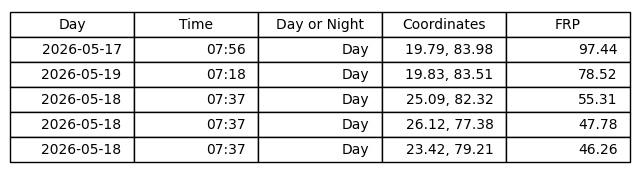

In [4]:
# Select the top 5 fires with the highest FRP across all days
top5_fires = (
    clean_india_fires
    .nlargest(5, "frp")[["Day", "Time", "Day or Night", "Coordinates", "frp"]]
    .rename(columns={"frp": "FRP"})
)

save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_top5_fires.png"

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

# Create table
table = ax.table(
    cellText=top5_fires.values,
    colLabels=top5_fires.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

# Save the figure
plt.savefig(save_path, bbox_inches='tight', dpi=300)

# Show table
plt.show()

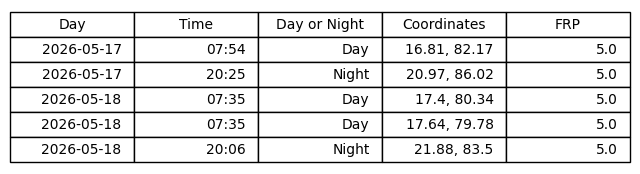

In [5]:
# Select the top 5 fires with the smallest FRP across all days
bottom5_fires = (
    clean_india_fires
    .nsmallest(5, "frp")[["Day", "Time", "Day or Night", "Coordinates", "frp"]]
    .rename(columns={"frp": "FRP"})
)

save_path = f"C:/Users/nekos/geo876-final-project/geo876-final-project/outputs/india_bottom5_fires.png"

fig, ax = plt.subplots(figsize=(8,2))
ax.axis('off')

# Create table
table = ax.table(
    cellText=bottom5_fires.values,
    colLabels=bottom5_fires.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1,1.5)

# Save the figure
plt.savefig(save_path, bbox_inches='tight', dpi=300)

# Show table
plt.show()